# Import Statements

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Task 1: Cleaning your data

## 1.

In [3]:
wine_df = pd.read_csv('winequality-red.csv')



wine_df.isna().sum().sort_values(ascending=False)


,0
total sulfur dioxide,98
density,76
pH,76
free sulfur dioxide,71
chlorides,50
residual sugar,44
citric acid,44
volatile acidity,22
sulphates,21
fixed acidity,0


In [4]:
wine_df['total sulfur dioxide'] = wine_df['total sulfur dioxide'].fillna(wine_df['total sulfur dioxide'].median())
wine_df['density'] = wine_df['density'].fillna(wine_df['density'].median())
wine_df['pH'] = wine_df['pH'].fillna(wine_df['pH'].median())
wine_df['free sulfur dioxide'] = wine_df['free sulfur dioxide'].fillna(wine_df['free sulfur dioxide'].median())
wine_df['residual sugar'] = wine_df['residual sugar'].fillna(wine_df['residual sugar'].median())
wine_df['chlorides'] = wine_df['chlorides'].fillna(wine_df['chlorides'].median())
wine_df['citric acid'] = wine_df['citric acid'].fillna(wine_df['citric acid'].median())
wine_df['volatile acidity'] = wine_df['volatile acidity'].fillna(wine_df['volatile acidity'].median())
wine_df['sulphates'] = wine_df['sulphates'].fillna(wine_df['sulphates'].median())

In [5]:

wine_df.isna().sum().sort_values(ascending=False)

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## 2.

copied from cleaned.py

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5  


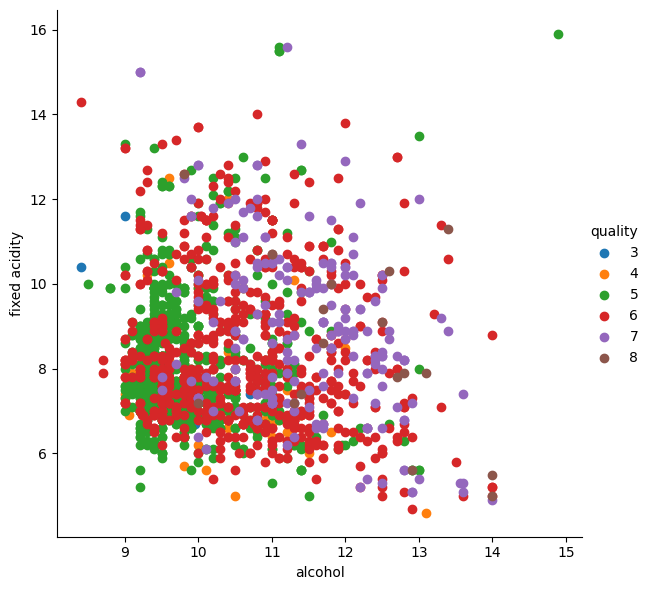

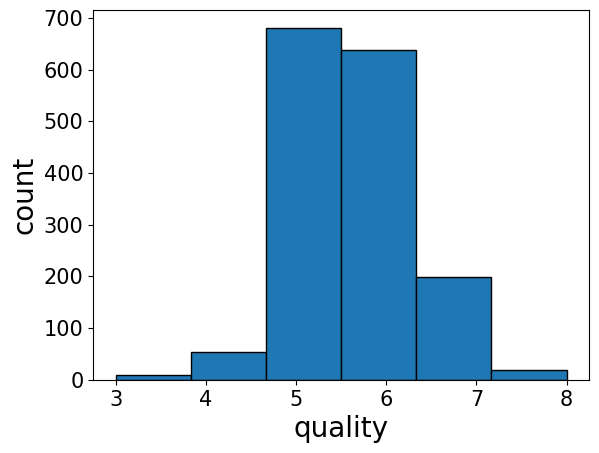

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

##plt.style.use('seaborn-darkgrid')

# Note that Best Practices, in terms of order of steps were violated in this program, please fix that.

# # Data Acquisition (I broke the CSV on purpose)
wine_df = pd.read_csv('winequality-red.csv')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(wine_df.head(3))

X = wine_df.drop('quality', axis=1).values
y = np.ravel(wine_df[['quality']])


## Based on the slides, best practice would be to split the data into training and testing sets before doing any EDA or cleaning.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



# # Cleanup

# # Exploratory Data Analysis
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    # print(wine_df.describe())
# sns.pairplot(wine_df, hue = 'quality', height = 3, palette="husl")
# sns.violinplot(data=wine_df, x='quality', y='alcohol')
sns.FacetGrid(wine_df, hue='quality', height=6).map(plt.scatter, 'alcohol', 'fixed acidity').add_legend()
plt.show()


# ### Distribution of wine quality (target variable)
plt.hist(wine_df['quality'], bins=6, edgecolor='black')
plt.xlabel('quality', fontsize=20)
plt.ylabel('count', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


## Some descriptive stats on the data

In [7]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1577.000000,1555.000000,1555.000000,1.549000e+03,1528.000000,1501.000000,1523.000000,1523.000000,1578.000000,1599.000000,1599.000000
mean,8.319637,0.528662,0.268328,2.531029,6.455778e+10,15.928665,46.215190,0.996698,3.314156,0.659043,10.422983,5.636023
std,1.741096,0.178990,0.194905,1.381187,2.540822e+12,10.414376,32.631079,0.001897,0.154067,0.170195,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,1.200000e-02,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,7.000000e-02,8.000000,22.000000,0.995540,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,7.900000e-02,14.000000,38.000000,0.996690,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,9.000000e-02,21.000000,62.000000,0.997800,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.400000,1.000000e+14,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Task 2: Scaling your data

## 1.

In [8]:
X = wine_df.drop(columns='quality')
y = wine_df['quality']



knn = KNeighborsClassifier(n_neighbors=5)

## 2.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 3.

In [10]:
scl = StandardScaler()
X_train_scaled = scl.fit_transform(X_train)
X_test_scaled = scl.transform(X_test)

## 4.

In [11]:
wine_df = pd.read_csv('winequality-red.csv')

wine_df['total sulfur dioxide'] = wine_df['total sulfur dioxide'].fillna(wine_df['total sulfur dioxide'].median())
wine_df['density'] = wine_df['density'].fillna(wine_df['density'].median())
wine_df['pH'] = wine_df['pH'].fillna(wine_df['pH'].median())
wine_df['free sulfur dioxide'] = wine_df['free sulfur dioxide'].fillna(wine_df['free sulfur dioxide'].median())
wine_df['residual sugar'] = wine_df['residual sugar'].fillna(wine_df['residual sugar'].median())
wine_df['chlorides'] = wine_df['chlorides'].fillna(wine_df['chlorides'].median())
wine_df['citric acid'] = wine_df['citric acid'].fillna(wine_df['citric acid'].median())
wine_df['volatile acidity'] = wine_df['volatile acidity'].fillna(wine_df['volatile acidity'].median())
wine_df['sulphates'] = wine_df['sulphates'].fillna(wine_df['sulphates'].median())

X = wine_df.drop(columns='quality')
y = wine_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'scaler' : [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring = ['accuracy', 'f1_weighted'],
    refit = 'f1_weighted',
    n_jobs = 1
)


grid.fit(X_train, y_train)

print(f"Best Scaler and Parameters: {grid.best_params_}")
print(f"Best Weighted F1-Score: {grid.best_score_:.4f}")


results = pd.DataFrame(grid.cv_results_)
print(results[['param_scaler', 'param_knn__n_neighbors',
                'mean_test_accuracy', 'mean_test_f1_weighted']]
      .sort_values('mean_test_f1_weighted', ascending=False)
      .head(10))


Best Scaler and Parameters: {'knn__n_neighbors': 9, 'scaler': RobustScaler()}
Best Weighted F1-Score: 0.5714
        param_scaler  param_knn__n_neighbors  mean_test_accuracy  \
11    RobustScaler()                       9            0.594327   
20    RobustScaler()                      17            0.595191   
23    RobustScaler()                      19            0.593394   
26    RobustScaler()                      21            0.591620   
12  StandardScaler()                      11            0.588957   
14    RobustScaler()                      11            0.584509   
16    MinMaxScaler()                      15            0.586291   
17    RobustScaler()                      15            0.582683   
8     RobustScaler()                       7            0.580025   
24  StandardScaler()                      21            0.579136   

    mean_test_f1_weighted  
11               0.571418  
20               0.570828  
23               0.568590  
26               0.566440  
12

The parameter and scaler that achieve the best accuracy and weighted f1 score are n neighbours set to 0 and the Robust scaler, achieving an accuracy of 0.594327 and a weighted f1 score of 0.571418.


This may be attributed to class imbalance and the difficulty of classifying 6 classes. Since there are few examples of classes such as 3 and 8, there may never be enough neighbours to guess those classes, which drags the weighted f1 down.

RobustScaler is the best scaler because it is less sensitive to outliers so it can handle them better.

## 5.

In [12]:
n = grid.best_params_['knn__n_neighbors']
scaler = grid.best_params_['scaler']

knn = KNeighborsClassifier(n_neighbors=n)
scl = scaler

X_train_scaled = scl.fit_transform(X_train)
X_test_scaled = scl.transform(X_test)

knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)


cls_report = classification_report(y_test, y_pred, zero_division=0)
print(cls_report)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        17
           5       0.60      0.64      0.62       195
           6       0.52      0.59      0.55       200
           7       0.56      0.41      0.47        61
           8       0.00      0.00      0.00         6

    accuracy                           0.56       480
   macro avg       0.28      0.27      0.27       480
weighted avg       0.53      0.56      0.54       480



The macro F1 score of 0.27 and the weighted F1 score of almost double that (0.54) indicate that the model is failing on the rarer classes (3, 4, and 8). Macro f1 treats all classes equally, while the weighted f1 score is dominated by common classes (5 and 6).
The class imbalance may be the cause of the low performance, because if it were the choice of k or the scaler, then performance would be mediocre across all classes.

## 6.

In [13]:
bin_schemes = {
    'orig_low3-4':      [-np.inf, 4, 6, np.inf],
    'balanced_low3-5':  [-np.inf, 5, 6, np.inf],
    'wide_low_mid7':    [-np.inf, 5, 7, np.inf],
    'shift_right':      [-np.inf, 4, 7, np.inf],
}

for name, bins in bin_schemes.items():
    binned = pd.cut(wine_df['quality'], bins=bins, labels=["Low", "Mid", "High"])
    print(name, bins)
    print(binned.value_counts())
    print()

orig_low3-4 [-inf, 4, 6, inf]
quality
Mid     1319
High     217
Low       63
Name: count, dtype: int64

balanced_low3-5 [-inf, 5, 6, inf]
quality
Low     744
Mid     638
High    217
Name: count, dtype: int64

wide_low_mid7 [-inf, 5, 7, inf]
quality
Mid     837
Low     744
High     18
Name: count, dtype: int64

shift_right [-inf, 4, 7, inf]
quality
Mid     1518
Low       63
High      18
Name: count, dtype: int64



The bins create varying class imbalances that will affect the weighted and macro F1 scores.

The most balanced bins are balanced_low3-5, where it lumps quality 3-5 into a low bin; 6 is the midpoint, and the high category is 7 and 8.

Original_low3-4 lumps 3 and 4 into the low class, 5 and 6 into the mid class and 7 and 8 into the high class.

Wide_low_mid7 lumps 3,4, and 5 into the low class, 6 and 7 into the mid class, and 8 into the high class.

Shift_right bins 3,4 and into the low class, 5,6 and 7 into the mid class and 8 into the high class.


The assumption is that 3 indicates the lowest quality and 8 indicates the highest quality.

In [22]:
def best_candidate_bin(bin_candidate, scoring):

    binned = pd.cut(wine_df['quality'], bins=bin_candidate, labels=["Low", "Mid", "High"])
    wine_df['quality_category'] = binned

    new_X = wine_df.drop(columns=['quality', 'quality_category'])
    new_Y = wine_df['quality_category']

    X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
        new_X, new_Y, test_size=0.3, random_state=42
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])

    param_grid = {
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
        'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21]
    }

    new_grid = GridSearchCV(
        pipe, param_grid, cv=5,
        scoring=scoring, refit='f1_weighted', n_jobs=1
    )
    new_grid.fit(X_new_train, y_new_train)

    return {
        'bins': bin_candidate,
        'best_score': new_grid.best_score_,
        'best_params': new_grid.best_params_,
        'X_train': X_new_train, 'X_test': X_new_test,
        'y_train': y_new_train, 'y_test': y_new_test,
    }



scheme_results = {}
for name, bins in bin_schemes.items():
    scheme_results[name] = best_candidate_bin(bins, 'f1_weighted')
    print(name, scheme_results[name]['best_score'])

best_scheme_name = max(scheme_results, key=lambda k: scheme_results[k]['best_score'])
best_result = scheme_results[best_scheme_name]
print("Winning scheme:", best_scheme_name, best_result['best_params'])



orig_low3-4 0.8080775286022341
balanced_low3-5 0.6268352084529745
wide_low_mid7 0.7183853119653066
shift_right 0.927732878549843
Winning scheme: shift_right {'knn__n_neighbors': 7, 'scaler': MinMaxScaler()}


Shift_right yields the best weighted f1 score. This could be due to the mid bin containing most of the data.

In [23]:
n = best_result['best_params']['knn__n_neighbors']
scaler = best_result['best_params']['scaler']

knn = KNeighborsClassifier(n_neighbors=n)
scl = scaler

X_train_scaled = scl.fit_transform(best_result['X_train'])
X_test_scaled = scl.transform(best_result['X_test'])

knn.fit(X_train_scaled, best_result['y_train'])
y_pred = knn.predict(X_test_scaled)

print(classification_report(best_result['y_test'], y_pred, zero_division=0))

              precision    recall  f1-score   support

        High       0.00      0.00      0.00         6
         Low       0.00      0.00      0.00        18
         Mid       0.95      1.00      0.97       456

    accuracy                           0.95       480
   macro avg       0.32      0.33      0.32       480
weighted avg       0.90      0.95      0.93       480



Optimizing bin choice purely for weighted F1 selected the shift_right scheme, which put 95% of the test set into "Mid." The resulting model scored 0.95 accuracy and 0.93 weighted F1, but Low and High both scored 0.00 across precision, recall, and F1 therefore the model never correctly predicted either class. Weighted F1 rewards accuracy on the dominant class regardless of how the rest are handled, so an extremely imbalanced bin scheme can "win" on this metric without the model actually learning anything useful about the minority classes

## 7.

In [26]:
scheme_results_macro = {}
for name, bins in bin_schemes.items():
    scheme_results_macro[name] = best_candidate_bin(bins, 'f1_macro')
    print(name, scheme_results_macro[name]['best_score'])

best_scheme_name_macro = max(scheme_results_macro, key=lambda k: scheme_results_macro[k]['best_score'])
best_result_macro = scheme_results_macro[best_scheme_name_macro]
print("Winning scheme:", best_scheme_name_macro, best_result_macro['best_params'])

orig_low3-4 0.46843698870582273
balanced_low3-5 0.5844019604325974
wide_low_mid7 0.4837102780958765
shift_right 0.35021745451989045
Winning scheme: balanced_low3-5 {'knn__n_neighbors': 11, 'scaler': RobustScaler()}


In [27]:
n = best_result_macro['best_params']['knn__n_neighbors']
scaler = best_result_macro['best_params']['scaler']

knn = KNeighborsClassifier(n_neighbors=n)
scl = scaler

X_train_scaled = scl.fit_transform(best_result_macro['X_train'])
X_test_scaled = scl.transform(best_result_macro['X_test'])

knn.fit(X_train_scaled, best_result_macro['y_train'])
y_pred_macro = knn.predict(X_test_scaled)

print(classification_report(best_result_macro['y_test'], y_pred_macro, zero_division=0))

              precision    recall  f1-score   support

        High       0.52      0.49      0.50        67
         Low       0.65      0.66      0.66       213
         Mid       0.54      0.54      0.54       200

    accuracy                           0.59       480
   macro avg       0.57      0.56      0.57       480
weighted avg       0.58      0.59      0.58       480



Optimizing for macro F1 instead selected balanced_low3-5, which is far more evenly distributed (744/638/217). Overall accuracy dropped to 0.59, but F1 is now reasonably consistent across all three classes (0.66 Low, 0.54 Mid, 0.50 High) rather than collapsing to zero on two of them. This confirms macro F1 penalises ignoring small classes, so it favors bin schemes and models that perform adequately everywhere over ones that only excel on the majority class.